04/02/2026

In [19]:
import numpy as np
import matplotlib.pyplot as plt


Step size = 0.10
Local error:
 [0.         0.01873075 0.03032005 0.03681164 0.03972896 0.04019944
 0.03905021 0.03688176 0.03412436 0.03108116 0.0279611  0.02490381
 0.02199848 0.019298   0.0168296  0.0146027  0.01261471 0.01085527
 0.00930932 0.00795925 0.00678642]
Global error = 0.4800469939772947 


Step size = 0.50
Local error:
 [0.         0.36787944 0.13533528 0.04978707 0.01831564]
Global error = 0.5713174316646532 


Step size = 1.00
Local error:
 [0.         1.13533528 0.98168436]
Global error = 2.1170196443478786 


Step size = 1.50
Local error:
 [0.         2.01831564]
Global error = 2.018315638888734 



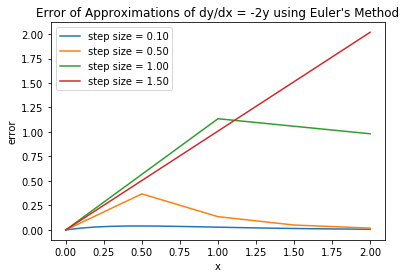

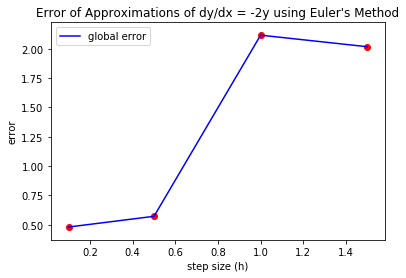

In [35]:
# Define parameters
h = np.array([.1, .5, 1, 1.5])  # step size
x_start, x_end = 0, 2
globalerror = []

# Function representing dy/dx = -2y
def f(x, y):
    return -2 * y

def exactSolution(x):
    return np.exp(-2 * x)

def error(y1, y2):
    localError = np.abs(y1 - y2)
    globalError = np.sum(localError)
    return localError, globalError


for j in range (0, len(h)):
    print("\nStep size =", f"{h[j]:.2f}")
    
    num_steps = int((x_end - x_start) / h[j])
    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)

    # Initial condition
    y_values[0] = 1  # y(0) = 1

    # Implement Euler's method
    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h[j] * f(x_values[i], y_values[i])
        
    # Calculate exact solution
    y_exact = exactSolution(x_values)
    
    # Calculate error
    localError, globalError = error(y_values, y_exact)
    globalerror.append(globalError)
        
    print("Local error:\n", localError)
    print("Global error =", globalError,"\n")
    
    plt.plot(x_values, localError, label=f"step size = {h[j]:.2f}")
    
# Plot the results
plt.xlabel('x')
plt.ylabel('error')
plt.title("Error of Approximations of dy/dx = -2y using Euler's Method")
plt.legend()
plt.show()

plt.plot(h, globalerror, 'b', label="global error")
plt.scatter(h, globalerror, color='r')
plt.xlabel('step size (h)')
plt.ylabel('error')
plt.title("Error of Approximations of dy/dx = -2y using Euler's Method")
plt.legend()
plt.show()

Citation: I searched up "how to use e for calculations in python", and used the source https://stackoverflow.com/questions/39154611/how-can-i-use-e-eulers-number-and-power-operation to learn the function "np.exp" which can be used instead of my original though of "math.e/math.exp".

For the local errors, as step size increases, the error increases faster and more dramatically since there are more drastic jumps between points on the graph. In general, the global error also increases as the step size increases.